Build Data Loader

In [70]:
import pandas as pd
import torch
from torchvision import transforms
from torch.utils.data import Dataset
from PIL import Image
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import transforms
from torch.utils.data import DataLoader
from sklearn.utils.class_weight import compute_class_weight
import pandas as pd
import numpy as np
from tqdm import tqdm

class DeepfakeDataset(Dataset):
    def __init__(self, csv_path, transform=None):
        self.data = pd.read_csv(csv_path, header=0)
        # Remove any rows where 'label' is not a digit (e.g., header rows)
        self.data = self.data[self.data['label'].astype(str).str.isdigit()]
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        img_path = self.data.iloc[idx]['filepath']
        label = int(self.data.iloc[idx]['label'])
        img = Image.open(img_path).convert('RGB')
        if self.transform:
            img = self.transform(img)
        return img, torch.tensor(label)               # Convert to tensor


In [71]:
import torch.nn as nn
import torch.nn.functional as F

class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 16, 3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(16, 32, 3, padding=1)
        self.fc1 = nn.Linear(32 * 56 * 56, 128)
        self.fc2 = nn.Linear(128, 2)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))  # [B, 16, 112, 112]
        x = self.pool(F.relu(self.conv2(x)))  # [B, 32, 56, 56]
        x = x.view(-1, 32 * 56 * 56)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x


Create Transformations

Initialize Datasets

In [ ]:
from sklearn.model_selection import train_test_split
import pandas as pd
import numpy as np
import torch
from torch.utils.data import DataLoader, WeightedRandomSampler
from torchvision import transforms
import albumentations as A
from albumentations.pytorch import ToTensorV2

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Load and split data
df = pd.read_csv("data/labels.csv", header=0)

# Calculate class distribution
class_counts = df['label'].value_counts()
print("Original class distribution:")
print(class_counts)

# Step 1: Split with stratification
train_df, val_df = train_test_split(
    df, 
    test_size=0.2, 
    stratify=df['label'], 
    random_state=42
)

# Step 2: Balance training data through oversampling
majority_count = train_df['label'].value_counts().max()
train_dfs = []

for label in train_df['label'].unique():
    label_df = train_df[train_df['label'] == label]
    # Oversample minority class
    resampled_df = label_df.sample(
        n=majority_count, 
        replace=True, 
        random_state=42
    )
    train_dfs.append(resampled_df)

balanced_train_df = pd.concat(train_dfs).reset_index(drop=True)
print("\nBalanced class distribution:")
print(balanced_train_df['label'].value_counts())

# Save balanced datasets
balanced_train_df.to_csv("train.csv", index=False)
val_df.to_csv("val.csv", index=False)

# Step 3: Enhanced transforms with augmentation
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], 
                       std=[0.229, 0.224, 0.225])  # ImageNet stats
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], 
                       std=[0.229, 0.224, 0.225])
])

# Step 4: Compute class weights for loss function
labels = balanced_train_df['label'].values
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(labels),
    y=labels
)
weights = torch.tensor(class_weights, dtype=torch.float).to(device)

# Step 5: Load datasets with separate transforms
train_dataset = DeepfakeDataset('train.csv', transform=train_transform)
val_dataset = DeepfakeDataset('val.csv', transform=val_transform)

# Step 6: Configure dataloaders
train_loader = DataLoader(
    train_dataset, 
    batch_size=32, 
    shuffle=True,  # Already balanced, so we can use shuffle
    num_workers=4,  # Parallel loading
    pin_memory=True  # Faster data transfer to GPU
)

val_loader = DataLoader(
    val_dataset, 
    batch_size=32, 
    shuffle=False,
    num_workers=4,
    pin_memory=True
)

# Model setup with improved initialization
model = SimpleCNN().to(device)
criterion = nn.CrossEntropyLoss(weight=weights)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-5)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, 
    mode='min', 
    factor=0.1, 
    patience=3
)

Original class distribution:
label
1    77627
0    16260
Name: count, dtype: int64

Balanced class distribution:
label
0    62101
1    62101
Name: count, dtype: int64


Define the Training Components

In [76]:
from tqdm import tqdm  # Import tqdm for progress bars


def train(model, train_loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0

    # Wrap the DataLoader with tqdm for a progress bar
    for images, labels in tqdm(train_loader, desc="Training", leave=False):
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()

    epoch_loss = running_loss / len(train_loader.dataset)
    accuracy = correct / len(train_loader.dataset)
    return epoch_loss, accuracy


def validate(model, val_loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0

    # Wrap the DataLoader with tqdm for a progress bar
    with torch.no_grad():
        for images, labels in tqdm(val_loader, desc="Validating", leave=False):
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()

    epoch_loss = running_loss / len(val_loader.dataset)
    accuracy = correct / len(val_loader.dataset)
    return epoch_loss, accuracy


# Configure DataLoader
train_loader = DataLoader(
    train_dataset, 
    batch_size=32, 
    shuffle=True,
    num_workers=0,  # Set to 0 first to test
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset, 
    batch_size=32, 
    shuffle=False,
    num_workers=0,  # Set to 0 first to test
    pin_memory=True
)

# Training loop
num_epochs = 10
best_val_loss = float('inf')

for epoch in range(num_epochs):
    print(f"Epoch {epoch+1}/{num_epochs}")
    train_loss, train_acc = train(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc = validate(model, val_loader, criterion, device)
    
    # Print metrics
    print(f"  Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"  Val   Loss: {val_loss:.4f} | Val   Acc: {val_acc:.4f}")
    
    # Save best model
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), 'best_model.pth')
        print("  Saved new best model!")
    
    # Update learning rate
    scheduler.step(val_loss)

Epoch 1/10


  Train Loss: 0.1494 | Train Acc: 0.9424
  Val   Loss: 0.1073 | Val   Acc: 0.9628
  Saved new best model!
Epoch 2/10


  Train Loss: 0.0702 | Train Acc: 0.9736
  Val   Loss: 0.0852 | Val   Acc: 0.9693
  Saved new best model!
Epoch 3/10


  Train Loss: 0.0551 | Train Acc: 0.9797
  Val   Loss: 0.0669 | Val   Acc: 0.9786
  Saved new best model!
Epoch 4/10


  Train Loss: 0.0507 | Train Acc: 0.9819
  Val   Loss: 0.0471 | Val   Acc: 0.9843
  Saved new best model!
Epoch 5/10


...

  Train Loss: 0.0408 | Train Acc: 0.9855
  Val   Loss: 0.0623 | Val   Acc: 0.9833
Epoch 7/10


  Train Loss: 0.0381 | Train Acc: 0.9864
  Val   Loss: 0.0301 | Val   Acc: 0.9914
  Saved new best model!
Epoch 8/10


  Train Loss: 0.0383 | Train Acc: 0.9870
  Val   Loss: 0.0382 | Val   Acc: 0.9884
Epoch 9/10


  Train Loss: 0.0343 | Train Acc: 0.9880
  Val   Loss: 0.0308 | Val   Acc: 0.9915
Epoch 10/10


  Train Loss: 0.0349 | Train Acc: 0.9881
  Val   Loss: 0.0320 | Val   Acc: 0.9895


In [78]:
import torch

# Make sure SimpleCNN class is defined above this cell!

model = SimpleCNN()
model.load_state_dict(torch.load('best_model.pth', map_location=torch.device('cpu')))
model.eval()

SimpleCNN(
  (conv1): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (fc1): Linear(in_features=100352, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=2, bias=True)
)

In [79]:
from PIL import Image
from torchvision import transforms
import torch

# Define the transform used during training
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

# Load an image
img_path = "data/cropped/val/real/real_001_frame1.jpg"  # 👈 Use any image path
image = Image.open(img_path).convert('RGB')
image = transform(image).unsqueeze(0)  # Add batch dimension

# Move to device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
image = image.to(device)
model = model.to(device)

# Run inference
with torch.no_grad():
    outputs = model(image)
    probs = torch.softmax(outputs, dim=1)
    pred = torch.argmax(probs, dim=1).item()

print(f"Predicted Class: {pred} ({'REAL' if pred == 0 else 'FAKE'})")


Predicted Class: 0 (REAL)


In [80]:
from sklearn.metrics import classification_report
all_preds, all_labels = [], []

model.eval()
with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        outputs = model(images)
        preds = torch.argmax(outputs, dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.numpy())

print(classification_report(all_labels, all_preds, target_names=["REAL", "FAKE"]))


              precision    recall  f1-score   support

        REAL       0.96      0.99      0.98      3252
        FAKE       1.00      0.99      0.99     15526

    accuracy                           0.99     18778
   macro avg       0.98      0.99      0.99     18778
weighted avg       0.99      0.99      0.99     18778



Matplotlib is building the font cache; this may take a moment.


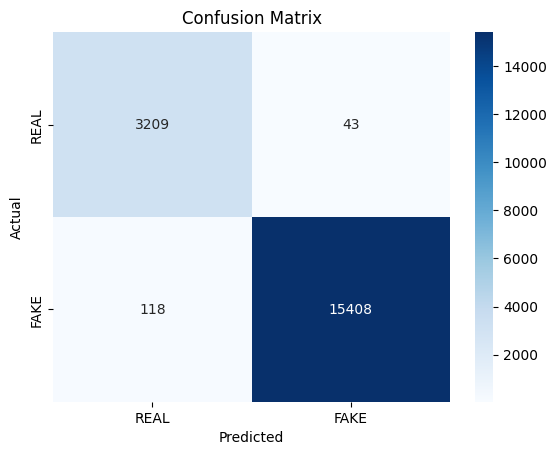

In [83]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(all_labels, all_preds)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["REAL", "FAKE"], yticklabels=["REAL", "FAKE"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


In [84]:
torch.save(model.state_dict(), "revealed_deepfake_detector.pth")